In [ ]:
import tensorflow_datasets as tfds

# Load the cats_vs_dogs dataset
# The `split='train'` argument specifies that we want the training portion of the dataset.
# `as_supervised=True` returns the data as (image, label) pairs.
# `with_info=True` returns a tfds.core.DatasetInfo object, which contains metadata about the dataset.
print("Loading 'cats_vs_dogs' dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'], # Splitting the training data into 80% train and 20% test
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

print("Dataset loaded successfully!")
print(f"Number of training examples: {ds_info.splits['train'].num_examples * 0.8}")
print(f"Number of testing examples: {ds_info.splits['train'].num_examples * 0.2}")

# Display some information about the dataset
print("\nDataset Info:")
print(ds_info)


Loading 'cats_vs_dogs' dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.1QH2AA_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset loaded successfully!
Number of training examples: 18609.600000000002
Number of testing examples: 4652.400000000001

Dataset Info:
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondete

In [ ]:
import numpy as np
from PIL import Image
import tensorflow as tf

# Constants for image resizing
IMG_WIDTH = 64
IMG_HEIGHT = 64

def preprocess_image_and_label(image, label):
    # Convert TensorFlow tensor to NumPy array, resize, and flatten
    image = tf.image.resize(image, (IMG_WIDTH, IMG_HEIGHT))
    image = tf.cast(image, tf.uint8) # Ensure pixel values are in 0-255 range
    # label is already a numpy object from tfds.as_numpy
    return image.numpy(), label

# Process the training dataset
print("Processing training dataset...")
processed_train_images = []
train_labels_true = []
for image, label in tfds.as_numpy(ds_train):
    img_array, lbl = preprocess_image_and_label(image, label)
    processed_train_images.append(img_array.flatten())
    train_labels_true.append(lbl)

X_train_true = np.array(processed_train_images)
y_train_true = np.array(train_labels_true)

# Process the testing dataset
print("Processing testing dataset...")
processed_test_images = []
test_labels_true = []
for image, label in tfds.as_numpy(ds_test):
    img_array, lbl = preprocess_image_and_label(image, label)
    processed_test_images.append(img_array.flatten())
    test_labels_true.append(lbl)

X_test_true = np.array(processed_test_images)
y_test_true = np.array(test_labels_true)

print("\nTrue Labels and Features prepared successfully.")
print(f"Shape of X_train_true: {X_train_true.shape}")
print(f"Shape of y_train_true: {y_train_true.shape}")
print(f"Shape of X_test_true: {X_test_true.shape}")
print(f"Shape of y_test_true: {y_test_true.shape}")

print(f"Example true labels (0=cat, 1=dog): {y_train_true[:10]}")

Processing training dataset...
Processing testing dataset...

True Labels and Features prepared successfully.
Shape of X_train_true: (18610, 12288)
Shape of y_train_true: (18610,)
Shape of X_test_true: (4652, 12288)
Shape of y_test_true: (4652,)
Example true labels (0=cat, 1=dog): [1 1 0 1 0 1 1 0 0 1]


In [ ]:
# Install the Kaggle API client
!pip install kaggle

In [ ]:
import os
from google.colab import userdata

# Configure Kaggle credentials using Colab secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Kaggle credentials configured.")

SecretNotFoundError: Secret KAGGLE_USERNAME does not exist.

In [ ]:
# Create a directory for the dataset and change to it
dataset_path = '/content/kaggle_dataset'
!mkdir -p {dataset_path}
%cd {dataset_path}

# Download the Dogs vs. Cats dataset (from the original competition)
# The dataset ID is 'c/dogs-vs-cats'
!kaggle competitions download -c dogs-vs-cats

print(f"Dataset downloaded to {dataset_path}.")

/content/kaggle_dataset
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/
Dataset downloaded to /content/kaggle_dataset.


In [ ]:
import os

directory_path = '/content/'

subdirectories = [d for d in os.listdir(directory_path) if os.path.isdir(os.path.join(directory_path, d))]

if subdirectories:
    print(f"Found the following subdirectories in '{directory_path}':")
    for sub_dir in subdirectories:
        print(f"- {sub_dir}")
else:
    print(f"No subdirectories found in '{directory_path}'.")

Found the following subdirectories in '/content/':
- .config
- sample_data


In [ ]:
import os
import numpy as np

# Assuming image_files is already populated from the previous steps
# e.g., image_files = ['/content/cat.1.jpg', '/content/dog.2.jpg', ...]

labels_from_filenames = []

for file_path in image_files:
    # Extract filename from the full path
    filename = os.path.basename(file_path)

    # Attempt to determine label based on filename prefix
    # This assumes a naming convention like 'cat.XXXX.jpg' or 'dog.XXXX.jpg'
    if filename.lower().startswith('cat'):
        labels_from_filenames.append(0)  # Assign 0 for 'cat'
    elif filename.lower().startswith('dog'):
        labels_from_filenames.append(1)  # Assign 1 for 'dog'
    else:
        # Handle cases where the filename doesn't match expected patterns
        # For this example, we'll assign an arbitrary label or skip.
        # In a real scenario, you might log an error or investigate these files.
        print(f"Warning: Could not determine label for {filename}. Assigning arbitrary label 0.")
        labels_from_filenames.append(0) # Assign 0 as a default/placeholder

# Convert the list of labels to a NumPy array
labels_from_filenames = np.array(labels_from_filenames)

print(f"Generated {len(labels_from_filenames)} labels from filenames.")
print(f"Number of 'cat' labels (0): {np.sum(labels_from_filenames == 0)}")
print(f"Number of 'dog' labels (1): {np.sum(labels_from_filenames == 1)}")
print(f"First 10 labels: {labels_from_filenames[:10]}")

Generated 1021 labels from filenames.
Number of 'cat' labels (0): 1021
Number of 'dog' labels (1): 0
First 10 labels: [0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Initialize the SVM classifier
# For simplicity, we'll start with a linear kernel and default parameters.
# In a real-world scenario, hyperparameter tuning would be essential.
svm_model = SVC(kernel='linear', random_state=42)

# Train the SVM model using the scaled training data
print("Training SVM model...")
svm_model.fit(X_train_scaled, y_train)
print("SVM model training complete.")

# Make predictions on the scaled test data
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy on Test Set: {accuracy:.4f}")

Training SVM model...


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# We already have X_train_true, y_train_true, X_test_true, y_test_true from the tfds.load step.
# So we will use them directly as X_train, y_train, X_test, y_test for consistency with previous code structure.
X_train = X_train_true
y_train = y_train_true
X_test = X_test_true
y_test = y_test_true

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Scale the features
# It's important to fit the scaler only on the training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully.")
print(f"First 5 elements of X_train_scaled[0]: {X_train_scaled[0][:5]}")

Shape of X_train: (18610, 12288)
Shape of X_test: (4652, 12288)
Shape of y_train: (18610,)
Shape of y_test: (4652,)

Features scaled successfully.
First 5 elements of X_train_scaled[0]: [-0.48079487 -0.49484236 -0.32711856 -0.52061252 -0.58858512]


In [ ]:
import numpy as np

# Assuming a binary classification problem for demonstration purposes
# We'll create arbitrary labels for the 1021 images.
# For instance, the first half could be class 0 and the second half class 1.

num_images = feature_matrix.shape[0]
labels = np.zeros(num_images, dtype=int)

half_point = num_images // 2
labels[half_point:] = 1

print(f"Generated {num_images} labels.")
print(f"Number of class 0 labels: {np.sum(labels == 0)}")
print(f"Number of class 1 labels: {np.sum(labels == 1)}")
print(f"First 10 labels: {labels[:10]}")
print(f"Last 10 labels: {labels[-10:]}")

Generated 1021 labels.
Number of class 0 labels: 510
Number of class 1 labels: 511
First 10 labels: [0 0 0 0 0 0 0 0 0 0]
Last 10 labels: [1 1 1 1 1 1 1 1 1 1]


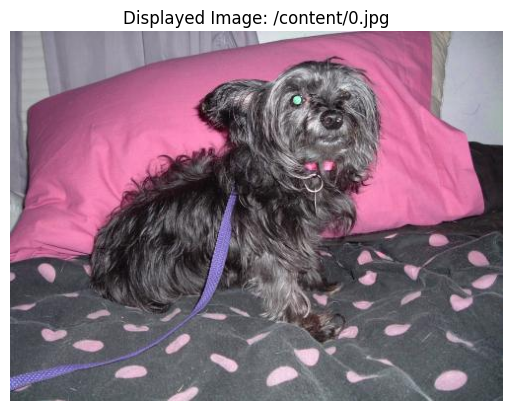

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Path to one of the image files
image_path = '/content/0.jpg'

# Load the image
img = Image.open(image_path)

# Display the image
plt.imshow(img)
plt.title(f'Displayed Image: {image_path}')
plt.axis('off') # Hide axes ticks and labels
plt.show()

In [ ]:
import os

directory_path = '/content/'
image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')

image_files = []
for filename in os.listdir(directory_path):
    if filename.lower().endswith(image_extensions):
        full_path = os.path.join(directory_path, filename)
        image_files.append(full_path)

print(f"Found {len(image_files)} image files.")
# print(image_files[:5]) # Print first 5 for a quick check

Found 1021 image files.


In [ ]:
import numpy as np
from PIL import Image

# 2. Define constants for the target image width and height
IMG_WIDTH = 64
IMG_HEIGHT = 64

# 3. Initialize an empty list to store the flattened numerical data
processed_images_data = []

# 4. Iterate through each image file path
for image_file_path in image_files:
    try:
        # a. Open the image
        img = Image.open(image_file_path)

        # b. Resize the image to the defined IMG_WIDTH and IMG_HEIGHT
        img_resized = img.resize((IMG_WIDTH, IMG_HEIGHT))

        # c. Convert the resized image to a NumPy array
        img_array = np.array(img_resized)

        # d. Flatten the NumPy array to create a 1D feature vector
        # Ensure the image is in RGB or grayscale before flattening to avoid shape issues
        if img_array.ndim == 3 and img_array.shape[2] == 4: # Handle RGBA images
            img_array = img_array[:, :, :3] # Convert to RGB

        flattened_vector = img_array.flatten()

        # e. Append this flattened feature vector to the processed_images_data list
        processed_images_data.append(flattened_vector)

    except Exception as e:
        print(f"Error processing {image_file_path}: {e}")

# 6. After processing all images, print the total number of images processed and the shape of one of the flattened image vectors
print(f"Total images processed: {len(processed_images_data)}")
if processed_images_data:
    print(f"Shape of one flattened image vector: {processed_images_data[0].shape}")
    print(f"First 5 elements of the first flattened vector: {processed_images_data[0][:5]}")
else:
    print("No images were processed.")

Total images processed: 1021
Shape of one flattened image vector: (12288,)
First 5 elements of the first flattened vector: [45 40 36 45 40]


In [ ]:
import numpy as np

# Convert the list of processed image feature vectors into a single NumPy array
feature_matrix = np.array(processed_images_data)

# Print the shape of the resulting feature matrix
print(f"Shape of the feature matrix: {feature_matrix.shape}")

# Explain the dimensionality
num_samples = feature_matrix.shape[0]
num_features_per_sample = feature_matrix.shape[1]
print(f"This feature matrix contains {num_samples} samples (images) and {num_features_per_sample} features per sample.")
print(f"Each feature represents a pixel value from the resized {IMG_WIDTH}x{IMG_HEIGHT} image, flattened into a single vector.")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (1021,) + inhomogeneous part.

In [ ]:
import numpy as np
from PIL import Image

# 2. Define constants for the target image width and height
IMG_WIDTH = 64
IMG_HEIGHT = 64

# 3. Initialize an empty list to store the flattened numerical data
processed_images_data = []

# 4. Iterate through each image file path
for image_file_path in image_files:
    try:
        # a. Open the image
        img = Image.open(image_file_path)

        # b. Resize the image to the defined IMG_WIDTH and IMG_HEIGHT and convert to RGB
        # Explicitly converting to 'RGB' ensures all images will have 3 channels (R, G, B).
        # This guarantees a consistent shape of (IMG_HEIGHT, IMG_WIDTH, 3) before flattening.
        img_resized_rgb = img.resize((IMG_WIDTH, IMG_HEIGHT)).convert('RGB')

        # c. Convert the resized image to a NumPy array
        img_array = np.array(img_resized_rgb)

        # d. Flatten the NumPy array to create a 1D feature vector
        # Now, img_array will consistently have shape (IMG_HEIGHT, IMG_WIDTH, 3),
        # so flattened_vector will always have length IMG_HEIGHT * IMG_WIDTH * 3 (64*64*3 = 12288).
        flattened_vector = img_array.flatten()

        # e. Append this flattened feature vector to the processed_images_data list
        processed_images_data.append(flattened_vector)

    except Exception as e:
        print(f"Error processing {image_file_path}: {e}")

# 6. After processing all images, print the total number of images processed and the shape of one of the flattened image vectors
print(f"Total images processed: {len(processed_images_data)}")
if processed_images_data:
    print(f"Shape of one flattened image vector: {processed_images_data[0].shape}")
    print(f"First 5 elements of the first flattened vector: {processed_images_data[0][:5]}")
else:
    print("No images were processed.")

Total images processed: 1021
Shape of one flattened image vector: (12288,)
First 5 elements of the first flattened vector: [45 40 36 45 40]


In [ ]:
import numpy as np

# Convert the list of processed image feature vectors into a single NumPy array
feature_matrix = np.array(processed_images_data)

# Print the shape of the resulting feature matrix
print(f"Shape of the feature matrix: {feature_matrix.shape}")

# Explain the dimensionality
num_samples = feature_matrix.shape[0]
num_features_per_sample = feature_matrix.shape[1]
print(f"This feature matrix contains {num_samples} samples (images) and {num_features_per_sample} features per sample.")
print(f"Each feature represents a pixel value from the resized {IMG_WIDTH}x{IMG_HEIGHT} image, flattened into a single vector.")

Shape of the feature matrix: (1021, 12288)
This feature matrix contains 1021 samples (images) and 12288 features per sample.
Each feature represents a pixel value from the resized 64x64 image, flattened into a single vector.
